<div dir="rtl" style="text-align: right;">

# تحلیل داده به روش PCA

### هدف: تشخیص اینکه کدام ارقام دست‌نویس با استفاده از روش PCA بیشتر از بقیه متمایز هستند.  
فرض کنید در حال کار روی یک سرویس تشخیص تصویر برای یک شرکت پستی هستیم. این سرویس قصد دارد تا ارقام دست‌نویس را به صورت خودکار تشخیص دهد. (این روش در حال توسط خدمات پستی مدرن مورد استفاده قرار گرفته و حتی از دقت بیشتری نسبت به انسان برخوردار است).  
شرکت پستی می‌خواهد بداند کدام ارقام دست‌نویس سخت‌تر قابل تشخیص هستند (نسبت به یکدیگر) تا بتواند روی جمع‌آوری نمونه‌های بیشتری از آن داده‌ها تمرکز کند.  
ما یک دیتاست از ارقام دست‌نویس در اختیار خواهیم داشت و باید با استفاده از روش PCA مولفه های اصلی آنها را جدا کرده و تشخیص دهیم که کدام ارقام به راحتی از بقیه قابل تمایز هستند.

</div>


<div dir="rtl" style="text-align: right;">

#### کتابخانه‌های مورد نیاز:

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

<div dir="rtl" style="text-align: right;">

#### در خانه پایین, اطلاعات موجود در فایل digits.csv را به صورت یک dataframe لود می‌کنیم و ستون‌های اضافی آن (ستون number_lable) را حذف می‌کنیم و آن را نمایش می‌دهیم.

</div>

In [2]:
df = pd.read_csv("digits.csv")
df1 = df

In [3]:
row = df.shape[0] 
column = df.shape[1] 

print("number of rows (datas + 1): ", row)
print("number of columns (features + 1): ",column)

number of rows (datas + 1):  1797
number of columns (features + 1):  65


In [4]:
df = df.iloc[0:row,0:column-1]     # delete labels
display(df)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


<div dir="rtl" style="text-align: right;">

#### یکی از تصاویر موجود در فایل (که به صورت یک بردار در فایل موجود است) را انتخاب کرده و آن را نمایش می‌دهیم.

</div>

In [5]:
sample = 1792
df_prime = df.iloc[sample]                    # choose a sample
df_prime = df_prime.values.reshape(8,8)     # turn the vector into a 8*8 matrix

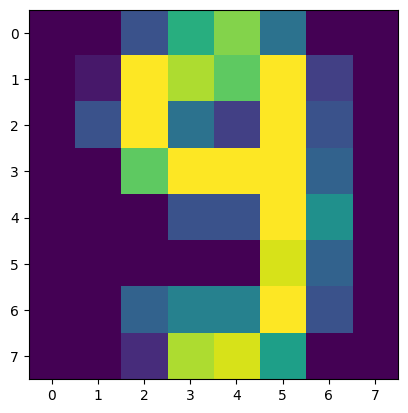

In [7]:
plt.imshow(df_prime)                        # show a picture of the handwritten digit

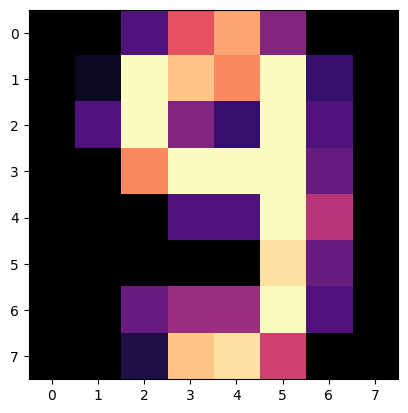

In [8]:
plt.imshow(df_prime, cmap="magma")

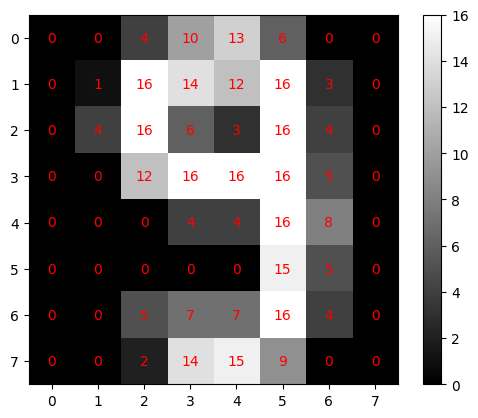

In [ ]:
plt.imshow(df_prime, cmap="gray")
plt.colorbar()

for i in range(df_prime.shape[0]):
    for j in range(df_prime.shape[1]):
        plt.text(j, i, int(df_prime[i, j]), ha="center", va="center", color="red")


<div dir="rtl" style="text-align: right;">

####  در مرحله اول, برای بدست آوردن نتایج درست باید اطلاعات را اسکیل کنیم تا مقادیر بزرگ تر باعث bias شدن نتایج نشود.

</div>

In [ ]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std = np.where(std==0, 1, std)        # prevent from NaN values
    return (X - mean) / std

numeric_data = df.select_dtypes(include=[np.number])

standardized_array = standardize(numeric_data)

display(pd.DataFrame(standardize(numeric_data)))

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,-0.335016,-0.043081,0.274072,-0.664478,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,0.086719,0.208293,-0.366771,-1.146647,-0.505670,-0.196008
1,0.0,-0.335016,-1.094937,0.038648,0.268751,-0.138020,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-0.249010,0.849632,0.548561,-0.505670,-0.196008
2,0.0,-0.335016,-1.094937,-1.844742,0.735366,1.097673,-0.409724,-0.125023,-0.059078,-0.624009,...,0.259230,-0.209785,-0.023596,-0.299081,-1.089383,-2.078218,-0.164037,1.565686,1.695137,-0.196008
3,0.0,-0.335016,0.377661,0.744919,0.268751,-0.844129,-0.409724,-0.125023,-0.059078,1.879691,...,1.072563,-0.209785,-0.023596,-0.299081,0.282736,0.208293,0.241430,0.379040,-0.505670,-0.196008
4,0.0,-0.335016,-1.094937,-2.551014,-0.197863,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-2.306869,0.849632,-0.468564,-0.505670,-0.196008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,-0.335016,-0.253452,-0.432200,0.268751,0.038508,-0.409724,-0.125023,-0.059078,-0.311047,...,0.055897,-0.209785,-0.023596,-0.299081,-0.697349,0.436944,0.646898,0.379040,-0.505670,-0.196008
1793,0.0,-0.335016,0.167290,0.980343,0.268751,0.921145,-0.108958,-0.125023,-0.059078,-0.624009,...,-0.554103,-0.209785,-0.023596,-0.299081,0.086719,0.894246,0.444164,-0.129523,-0.505670,-0.196008
1794,0.0,-0.335016,-0.884566,-0.196776,0.735366,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-0.697349,-0.706312,0.241430,-0.129523,-0.505670,-0.196008
1795,0.0,-0.335016,-0.674195,-0.432200,-1.131092,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.350769,-0.209785,-0.023596,-0.299081,-0.109298,-0.020358,0.849632,0.887602,-0.505670,-0.196008


<div dir="rtl" style="text-align: right;">
بخاطر استاندارد شدن، میانگین برابر صفر می‌شود.

</div>

In [11]:
print("not rounded mean: ", standardized_array.mean())

print("rounded mean: ", standardized_array.mean().round())

not rounded mean:  pixel_0_0    0.000000e+00
pixel_0_1   -3.558645e-17
pixel_0_2    3.163240e-17
pixel_0_3    3.954050e-17
pixel_0_4   -2.570132e-17
                 ...     
pixel_7_3   -1.897944e-16
pixel_7_4    2.372430e-17
pixel_7_5    4.349455e-17
pixel_7_6    7.908099e-18
pixel_7_7    2.372430e-17
Length: 64, dtype: float64
rounded mean:  pixel_0_0    0.0
pixel_0_1   -0.0
pixel_0_2    0.0
pixel_0_3    0.0
pixel_0_4   -0.0
            ... 
pixel_7_3   -0.0
pixel_7_4    0.0
pixel_7_5    0.0
pixel_7_6    0.0
pixel_7_7    0.0
Length: 64, dtype: float64


<div dir="rtl" style="text-align: right;">

####  باید با استفاده از PCA دو مولفه اصلی را پیدا کرده و مختصات پیکسل ها را بر این اساس چاپ کنیم.

</div>

In [13]:
cov_matrix = (standardized_array.T @ standardized_array) / (row-1)

print("covariance matrix:")
display(pd.DataFrame(cov_matrix))

covariance matrix:


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
pixel_0_0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pixel_0_1,0.0,1.000557,0.556928,0.207929,-0.018771,0.060810,0.048415,-0.038948,0.032338,0.556682,...,0.030970,-0.045368,-0.007910,0.856086,0.556036,0.147728,-0.102406,-0.029887,0.026562,-0.043913
pixel_0_2,0.0,0.556928,1.000557,0.560492,-0.084282,0.043593,0.002842,-0.062313,0.022324,0.582583,...,0.050877,-0.003806,-0.025851,0.515563,0.938145,0.500118,-0.134829,-0.041206,0.072639,0.082569
pixel_0_3,0.0,0.207929,0.560492,1.000557,0.023952,-0.171473,-0.115796,-0.040162,0.035683,0.328527,...,0.139475,0.075376,-0.049112,0.175902,0.560638,0.768373,-0.065993,-0.054966,0.053467,0.082016
pixel_0_4,0.0,-0.018771,-0.084282,0.023952,1.000557,0.508014,0.127835,0.010070,0.042089,0.051686,...,-0.265116,-0.212339,0.017362,-0.047250,-0.020187,-0.008872,-0.082171,-0.215929,-0.250838,-0.215469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel_7_3,0.0,0.147728,0.500118,0.768373,-0.008872,-0.068076,-0.045871,0.001013,0.043398,0.305361,...,0.094770,0.050060,-0.038269,0.113035,0.481979,1.000557,0.058423,-0.095009,0.006853,0.099727
pixel_7_4,0.0,-0.102406,-0.134829,-0.065993,-0.082171,-0.351342,-0.383735,-0.178343,0.049024,-0.000604,...,0.394499,0.105160,0.005700,-0.117973,-0.208072,0.058423,1.000557,0.609854,0.243441,0.103073
pixel_7_5,0.0,-0.029887,-0.041206,-0.054966,-0.215929,-0.268967,-0.304281,-0.141253,0.033428,0.071528,...,0.707913,0.262942,-0.003058,-0.043913,-0.091890,-0.095009,0.609854,1.000557,0.648689,0.262137
pixel_7_6,0.0,0.026562,0.072639,0.053467,-0.250838,-0.267808,-0.179044,-0.063256,0.020700,0.111631,...,0.602602,0.512011,-0.011939,0.014565,0.035388,0.006853,0.243441,0.648689,1.000557,0.620774


In [14]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

principal_components = eigenvectors[:, :2]

print("PCs")
display(pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(2)]))

PCs


,PC1,PC2
0,0.000000,0.000000
1,0.182234,-0.047027
2,0.285868,-0.059565
3,0.220370,0.020804
4,-0.025170,-0.155903
...,...,...
59,0.194449,0.009905
60,0.017774,0.251934
61,0.103198,0.242618
62,0.119811,0.165089


In [15]:
projected_data = np.dot(standardized_array, principal_components)

print("Projected Data:")
display(pd.DataFrame(projected_data, columns=[f'PC{i+1}' for i in range(2)]))

Projected Data:


,PC1,PC2
0,-1.914214,0.954502
1,-0.588980,-0.924636
2,-1.302039,0.317189
3,3.020770,0.868772
4,-4.528949,1.093480
...,...,...
1792,-0.104331,-0.255024
1793,-2.423234,1.429611
1794,-1.022596,0.147911
1795,-1.076055,0.380906


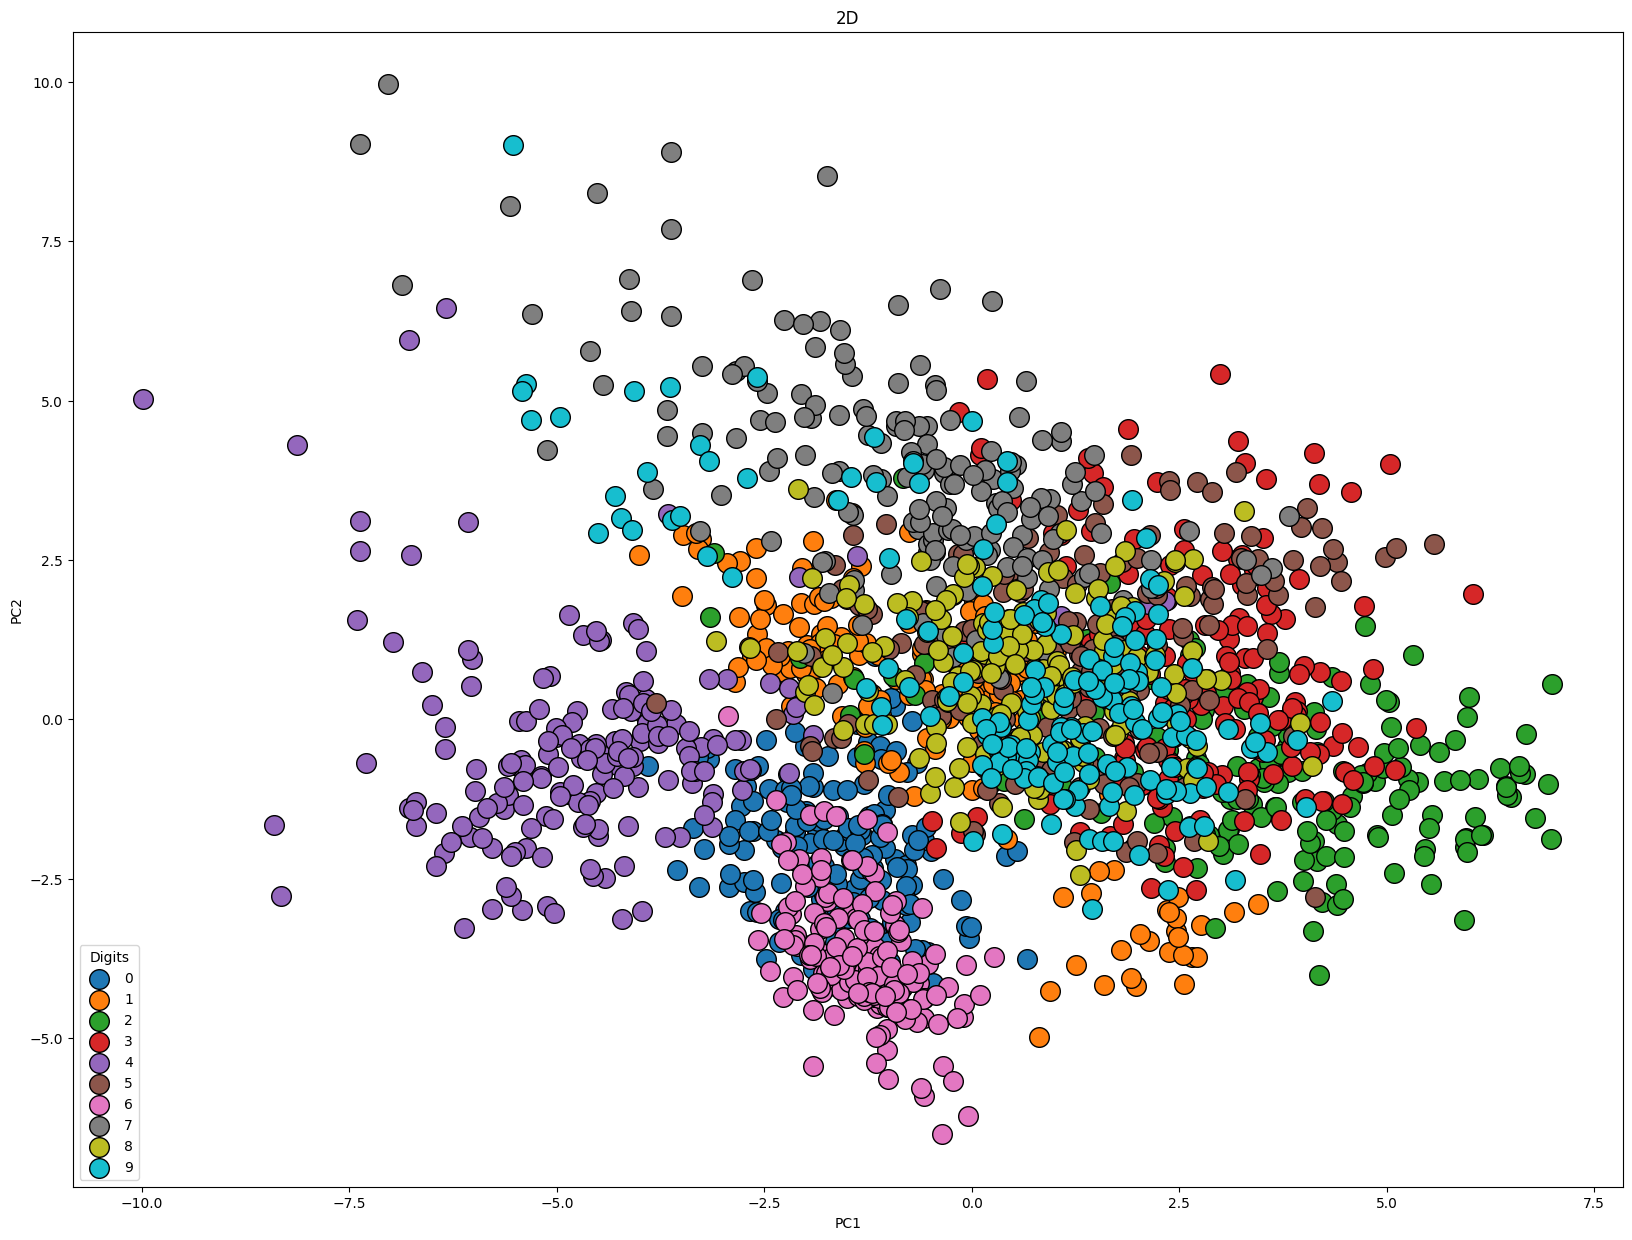

In [29]:
X = df1.iloc[: , 1:].values
Y = df1.iloc[: , -1].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(2)
X_pca = pca.fit_transform(X_scaled)

colors = plt.get_cmap('tab10', 10)


plt.figure(figsize=(20, 15))
for i in range(10):
    plt.scatter(X_pca[Y==i, 0],
                X_pca[Y==i, 1],
                color=colors(i),
                label=str(i),
                edgecolors='k',
                alpha=1,
                s=200
                )

plt.legend(title='Digits', loc='lower left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D")

plt.show()

<div dir="rtl" style="text-align: right;">

به‌دلیل استاندارد کردن، تراکم داده‌ها در اطراف صفر بیشتر می‌باشد.

رقم 7 در نمودار به طور شهودی بیشترین پراکندگی را دارد و رقم 6 به طور شهودی کمترین پراکندگی را دارد.

به طور شهودی ارقام 8 و 9 و 5 بیشترین تداخل را با یگدیگر ایجاد کرده‌اند.

ارقام 4، 6 و 2 به ترتیب کمترین تداخل را با سایر ارقام دارند.

</div>

<div dir="rtl" style="text-align: right;">

### در مرحله آخر, مشابه مرحله قبل سه مولفه اصلی PCA را پیدا می‌کنیم.

</div>

In [17]:
principal_components1 = eigenvectors[:, :3]

print("PCs")
display(pd.DataFrame(principal_components1, columns=[f'PC{i+1}' for i in range(3)]))

PCs


,PC1,PC2,PC3
0,0.000000,0.000000,0.000000
1,0.182234,-0.047027,0.023588
2,0.285868,-0.059565,-0.056799
3,0.220370,0.020804,-0.040464
4,-0.025170,-0.155903,-0.067065
...,...,...,...
59,0.194449,0.009905,-0.083464
60,0.017774,0.251934,-0.062455
61,0.103198,0.242618,-0.022280
62,0.119811,0.165089,0.100366


In [18]:
projected_data1 = np.dot(standardized_array, principal_components1)

print("Projected Data:")
display(pd.DataFrame(projected_data1, columns=[f'PC{i+1}' for i in range(3)]))

Projected Data:


,PC1,PC2,PC3
0,-1.914214,0.954502,-3.946035
1,-0.588980,-0.924636,3.924755
2,-1.302039,0.317189,3.023333
3,3.020770,0.868772,-0.801744
4,-4.528949,1.093480,0.973121
...,...,...,...
1792,-0.104331,-0.255024,-3.765861
1793,-2.423234,1.429611,-3.045245
1794,-1.022596,0.147911,2.469974
1795,-1.076055,0.380906,-2.455487


In [27]:
XX = df1.iloc[: , 0:-1].values
YY = df1.iloc[: , -1].values

scaler_prime = StandardScaler()
XXscaled = scaler_prime.fit_transform(XX)

pca_prime = PCA(3)
X_prime_pca = pca_prime.fit_transform(XXscaled)

df_plot = pd.DataFrame({
    'PC1': X_prime_pca[:, 0],
    'PC2': X_prime_pca[:, 1],
    'PC3': X_prime_pca[:, 2],
    'Label': YY
})

fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Label',
    color_continuous_scale='magma',
    title='3D PCA Plot',
    width=1000,
    height=800,
    opacity=0.9
)

fig.show()